In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.logger.logger import logging

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

# Load cleaned data
df = pd.read_excel('../data/processed/pulsemap_cleaned.xlsx')

logging.info("EDA notebook started - data loaded successfully")
print("Shape:", df.shape)
print(df.head(3))

Shape: (707, 21)
                 district                      state  bmi_below_normal_w  \
0                Nicobars  Andaman & Nicobar Islands                8.18   
1  North & Middle Andaman  Andaman & Nicobar Islands                8.55   
2           South Andaman  Andaman & Nicobar Islands               10.00   

   overweight_obese_w  anaemia_w  blood_sugar_w  blood_sugar_m  bp_elevated_w  \
0               39.11      38.30          13.05          15.39          35.36   
1               35.89      62.07          16.72          18.28          27.40   
2               39.01      57.66          18.41          18.10          22.95   

   bp_elevated_m  cervical_screening_w  ...  oral_exam_w  tobacco_w  \
0          46.97                 13.35  ...         5.37      63.46   
1          32.20                  1.70  ...        15.84      46.77   
2          26.90                  1.32  ...         8.00      19.60   

   tobacco_m  alcohol_w  alcohol_m  literacy_w  health_insurance  cl

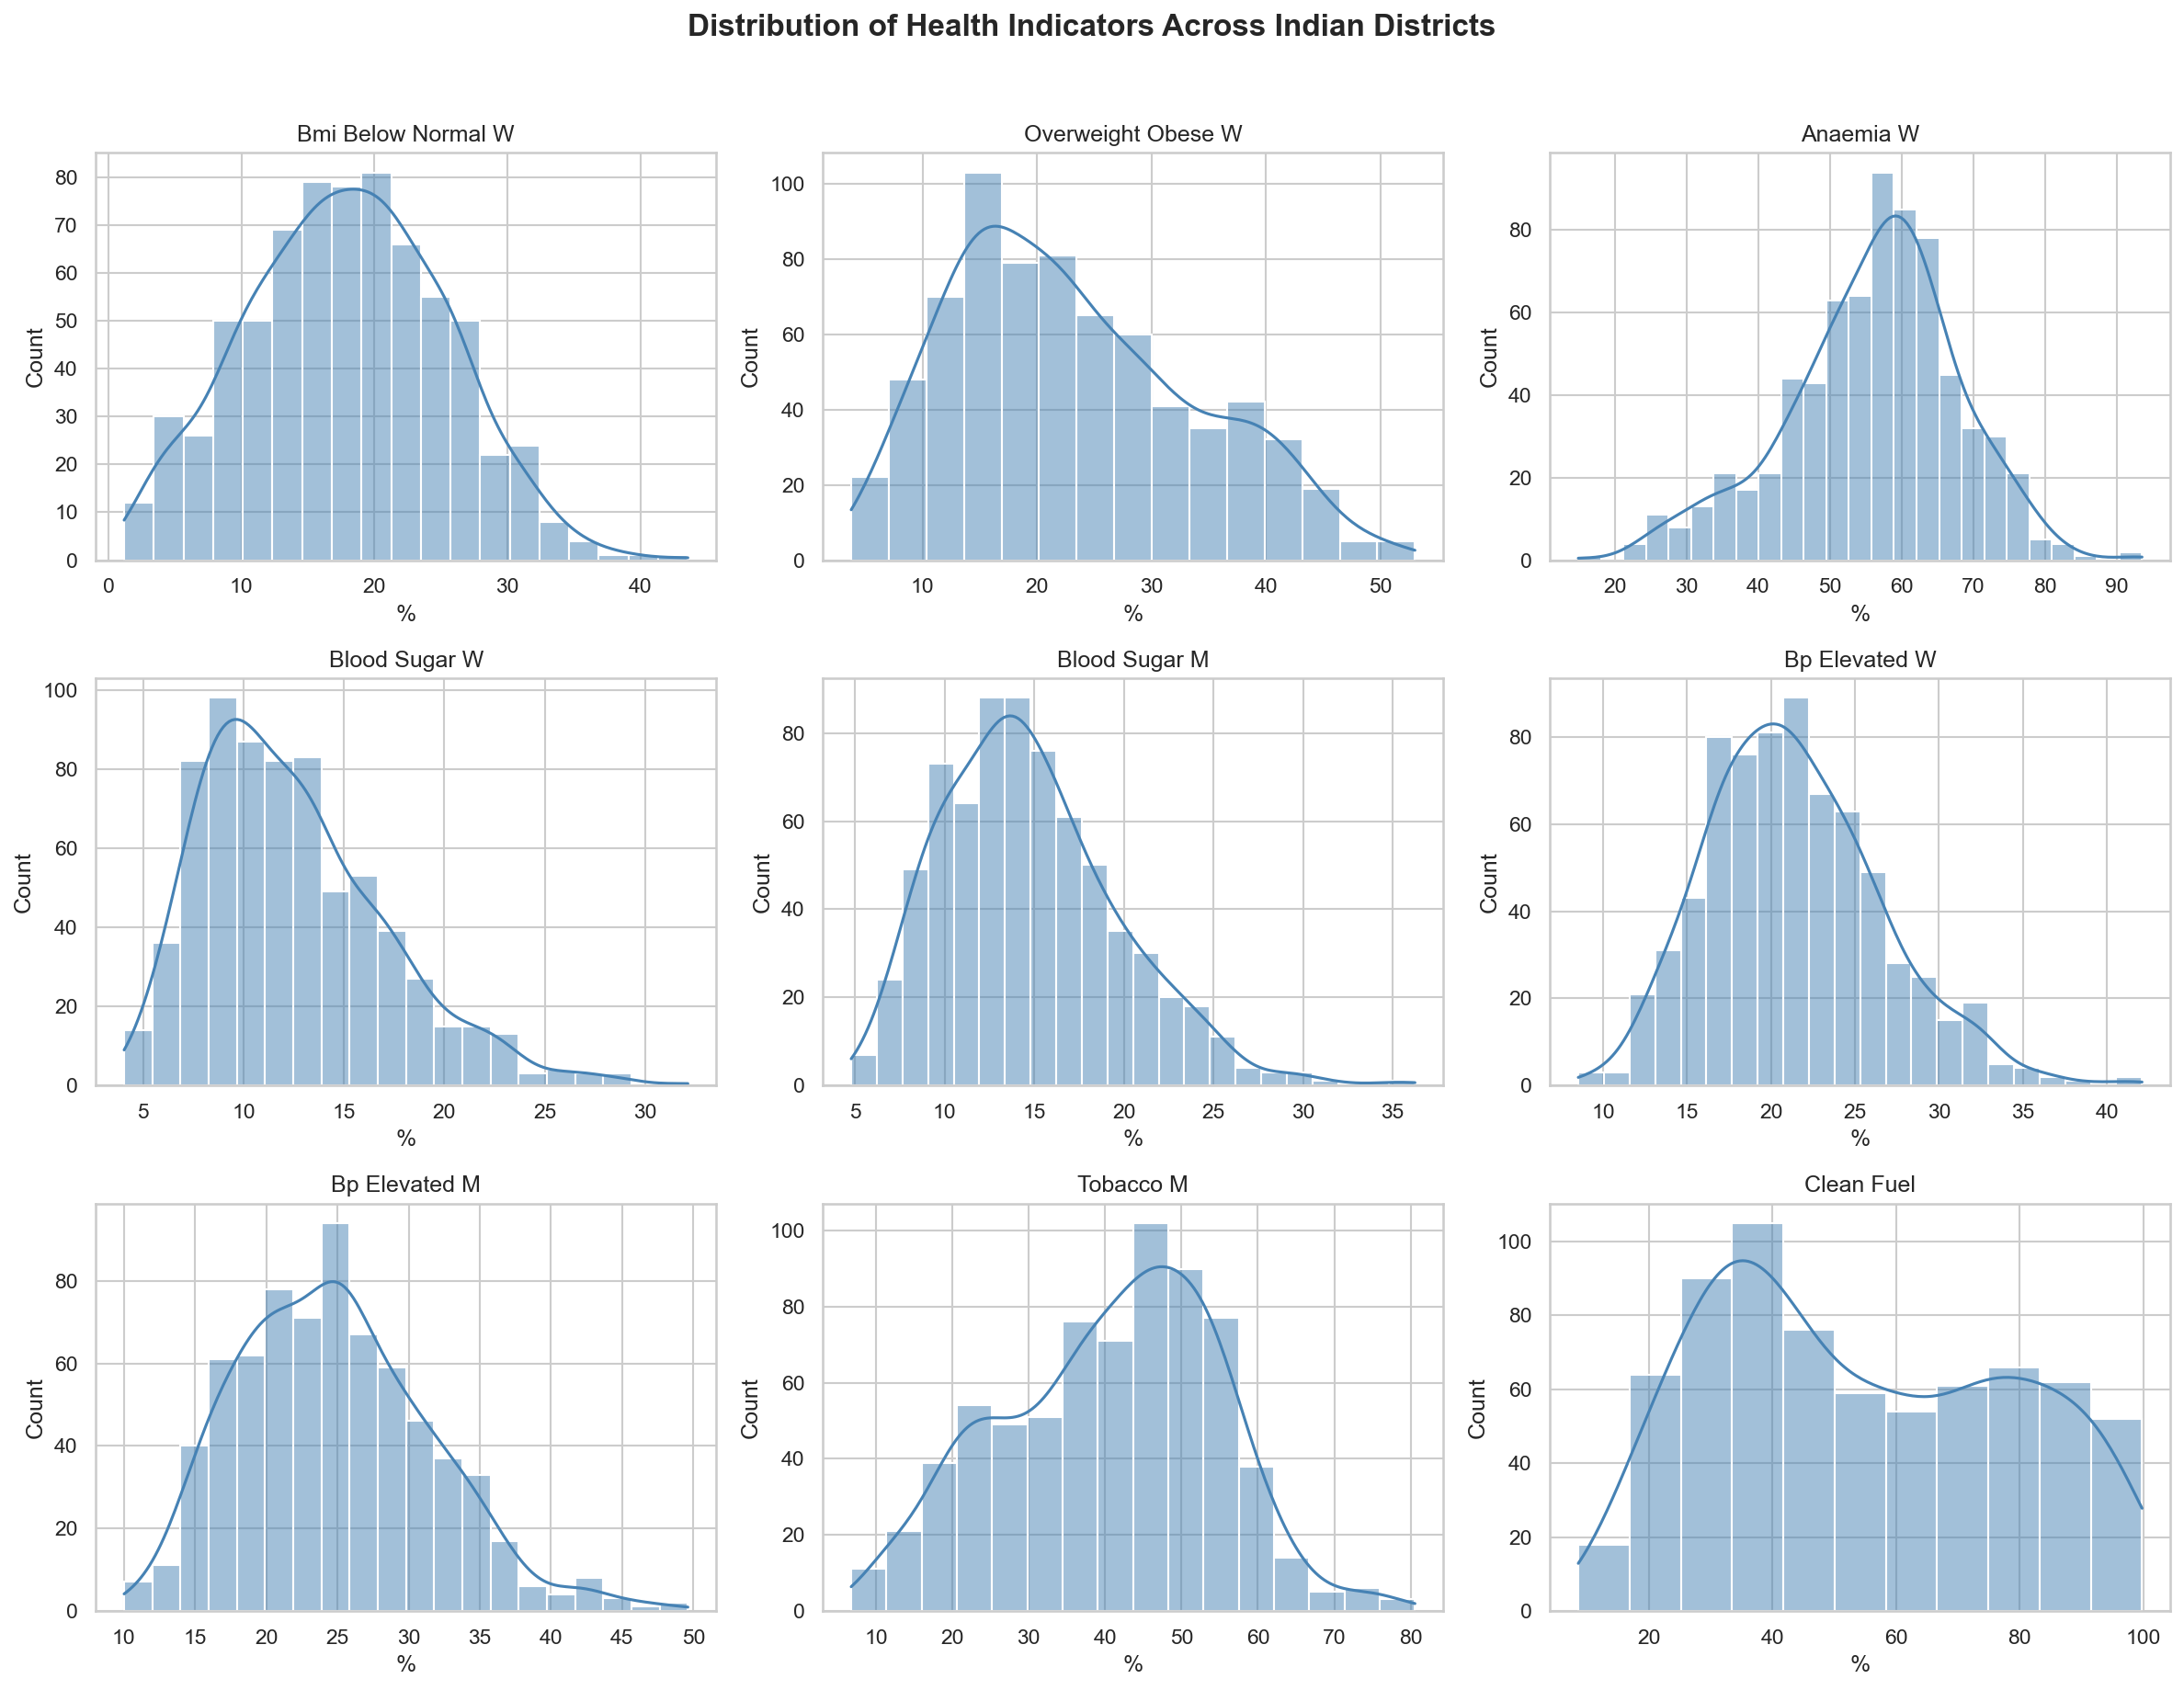

Done


In [2]:
# Distribution of key health indicators
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution of Health Indicators Across Indian Districts', 
             fontsize=16, fontweight='bold', y=1.02)

cols_to_plot = [
    'bmi_below_normal_w', 'overweight_obese_w', 'anaemia_w',
    'blood_sugar_w', 'blood_sugar_m', 'bp_elevated_w',
    'bp_elevated_m', 'tobacco_m', 'clean_fuel'
]

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col], ax=ax, kde=True, color='steelblue')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('%')

plt.tight_layout()
plt.savefig('../reports/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

logging.info("Distribution plots saved")
print("Done")

## EDA — Finding 1: Distribution Analysis

**Overall:** Most health indicators follow a near-normal distribution 
across 707 Indian districts, indicating consistent data collection 
without major bias.

**Key observations:**

- **BMI Below Normal (Women):** Right-skewed — majority of districts 
  have 10-25% undernourished women, with few districts showing extreme values.

- **Overweight/Obese (Women):** Slight right skew — urban districts 
  pulling the tail higher, dual burden of malnutrition visible.

- **Anaemia (Women):** Left-skewed — alarming. Most districts cluster 
  around 50-70%, meaning anaemia affects majority of women in average district.

- **Blood Sugar (Women & Men):** Near-normal, men slightly higher than 
  women on average — diabetes risk more pronounced in male population.

- **BP Elevated (Women & Men):** Normal distribution — men consistently 
  show higher BP prevalence than women across districts.

- **Tobacco (Men):** Wide spread — 10% to 80% range shows massive 
  state-level variation in tobacco use culture.

- **Clean Fuel:** Bimodal pattern — two distinct groups visible: 
  districts with low access (rural) and high access (urban). 
  Clear urban-rural divide.

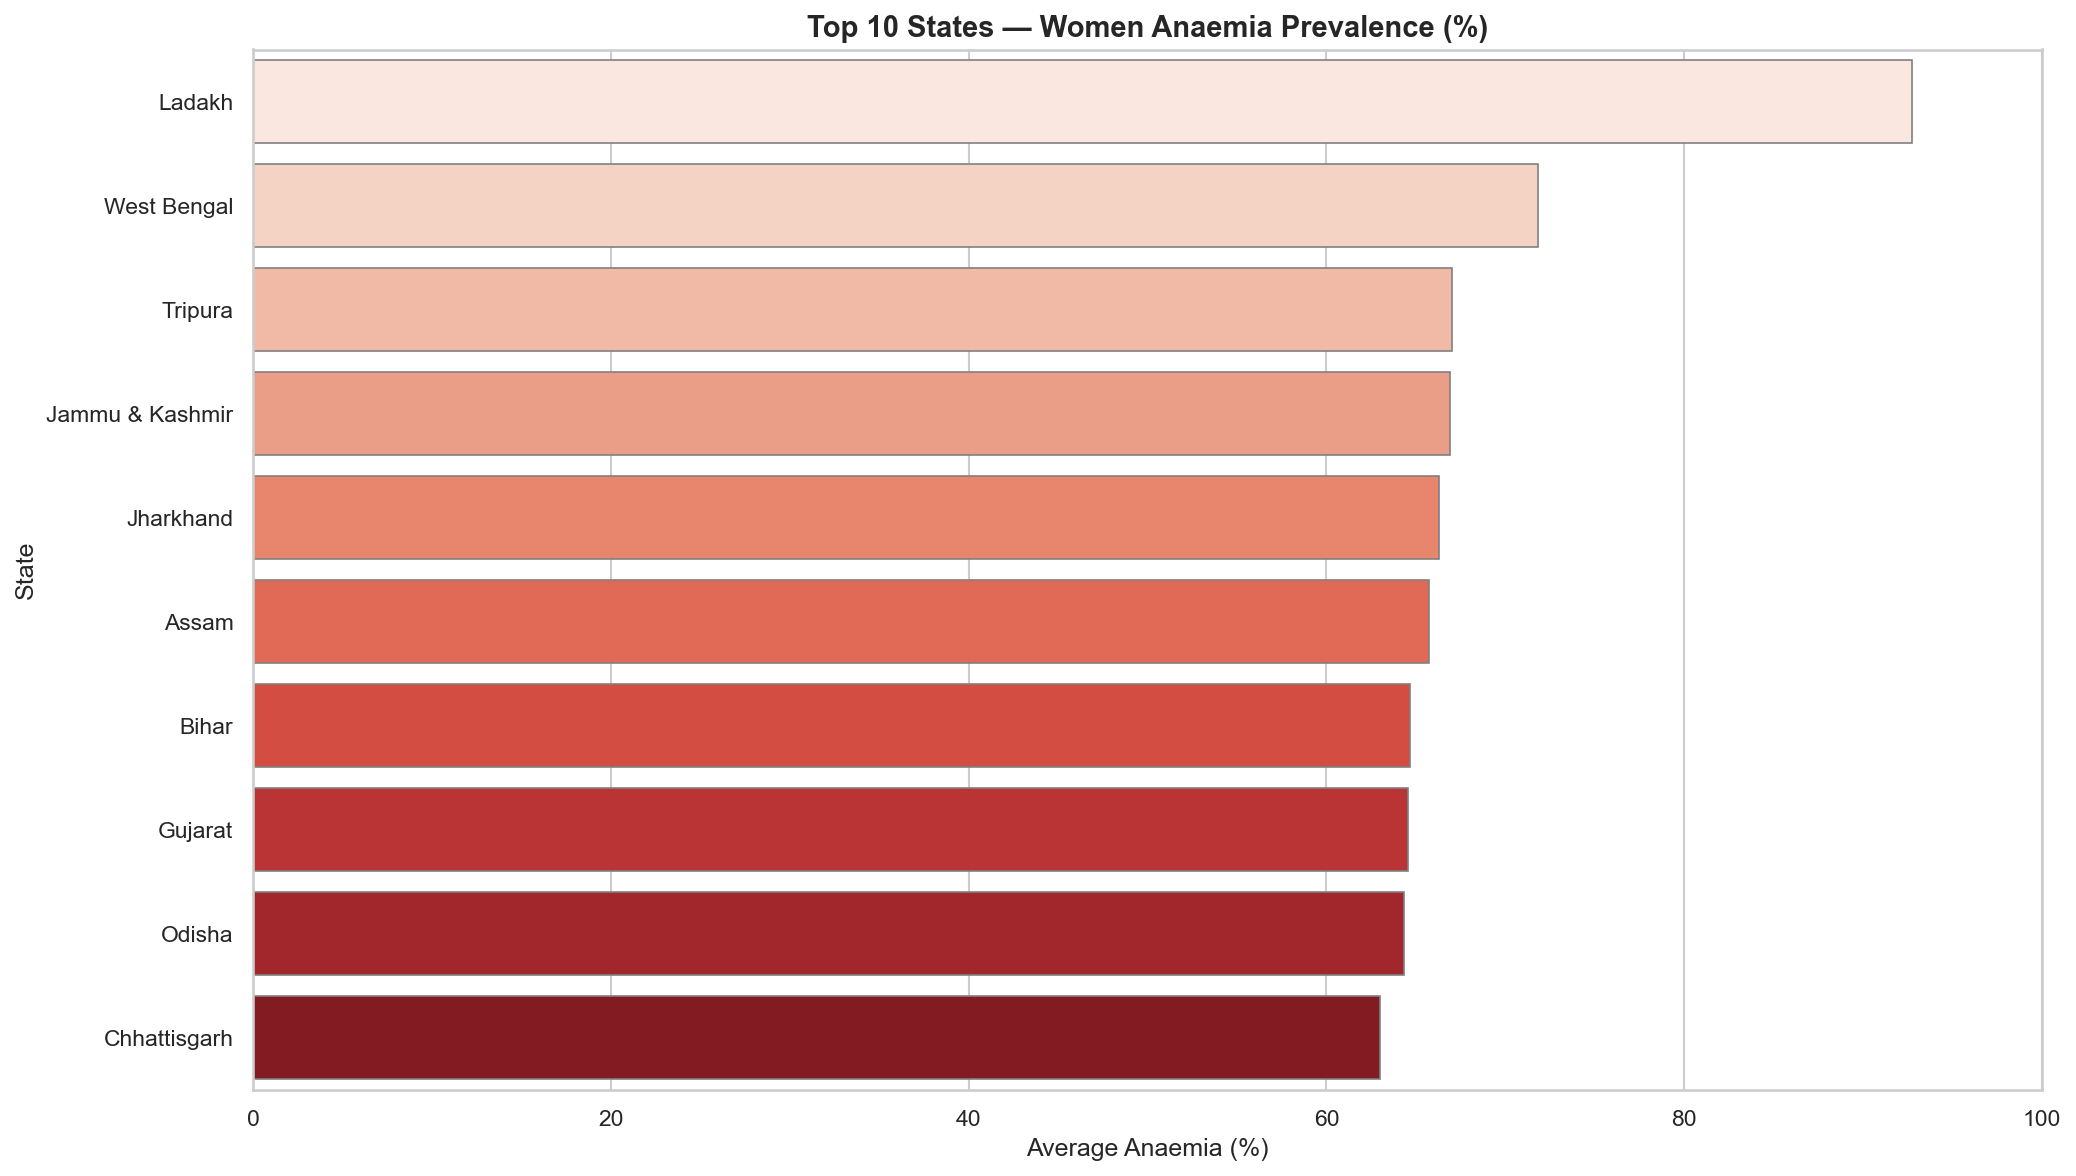

Done


In [3]:
# State-wise average risk indicators
state_avg = df.groupby('state')[['anaemia_w', 'blood_sugar_w', 
                                  'blood_sugar_m', 'bp_elevated_w',
                                  'bp_elevated_m', 'tobacco_m']].mean().round(2)
                                 
# Top 10 states by anaemia
top_anaemia = state_avg['anaemia_w'].sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 8))
sns.barplot(x=top_anaemia.values, y=top_anaemia.index,
            hue=top_anaemia.index, 
            palette='Reds', legend=False)
plt.title('Top 10 States — Women Anaemia Prevalence (%)', 
          fontweight='bold', fontsize=14)
plt.xlabel('Average Anaemia (%)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(0, 100)

# Edge visibility fix
for patch in plt.gca().patches:
    patch.set_edgecolor('gray')
    patch.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('../reports/02_top_states_anaemia.png', dpi=300, 
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("State-wise anaemia plot saved")
print("Done")

## Finding 2: Women Anaemia — State Level Analysis

**Key Observations:**

- **Ladakh** ranks highest with 90%+ anaemia prevalence — extreme 
  geographic isolation and limited healthcare access are primary drivers.

- **West Bengal** at ~70% is alarming given its relatively developed 
  urban infrastructure — suggesting rural-urban disparity within the state.

- **Tripura and J&K** both cross 67% — northeastern and border states 
  show consistently high anaemia burden.

- **Jharkhand, Assam, Bihar** — expected given high poverty rates and 
  nutritional deficiencies in these states.

- **Gujarat** is a surprising entry — an economically developed state 
  with high anaemia suggests dietary pattern issues over poverty.

- **Odisha and Chhattisgarh** complete the top 10 — tribal population 
  concentration correlates with limited nutrition access.

**Critical Insight:** All top 10 states show 63%+ average anaemia 
in women — this is not a regional problem, it is a national crisis 
requiring systemic intervention.

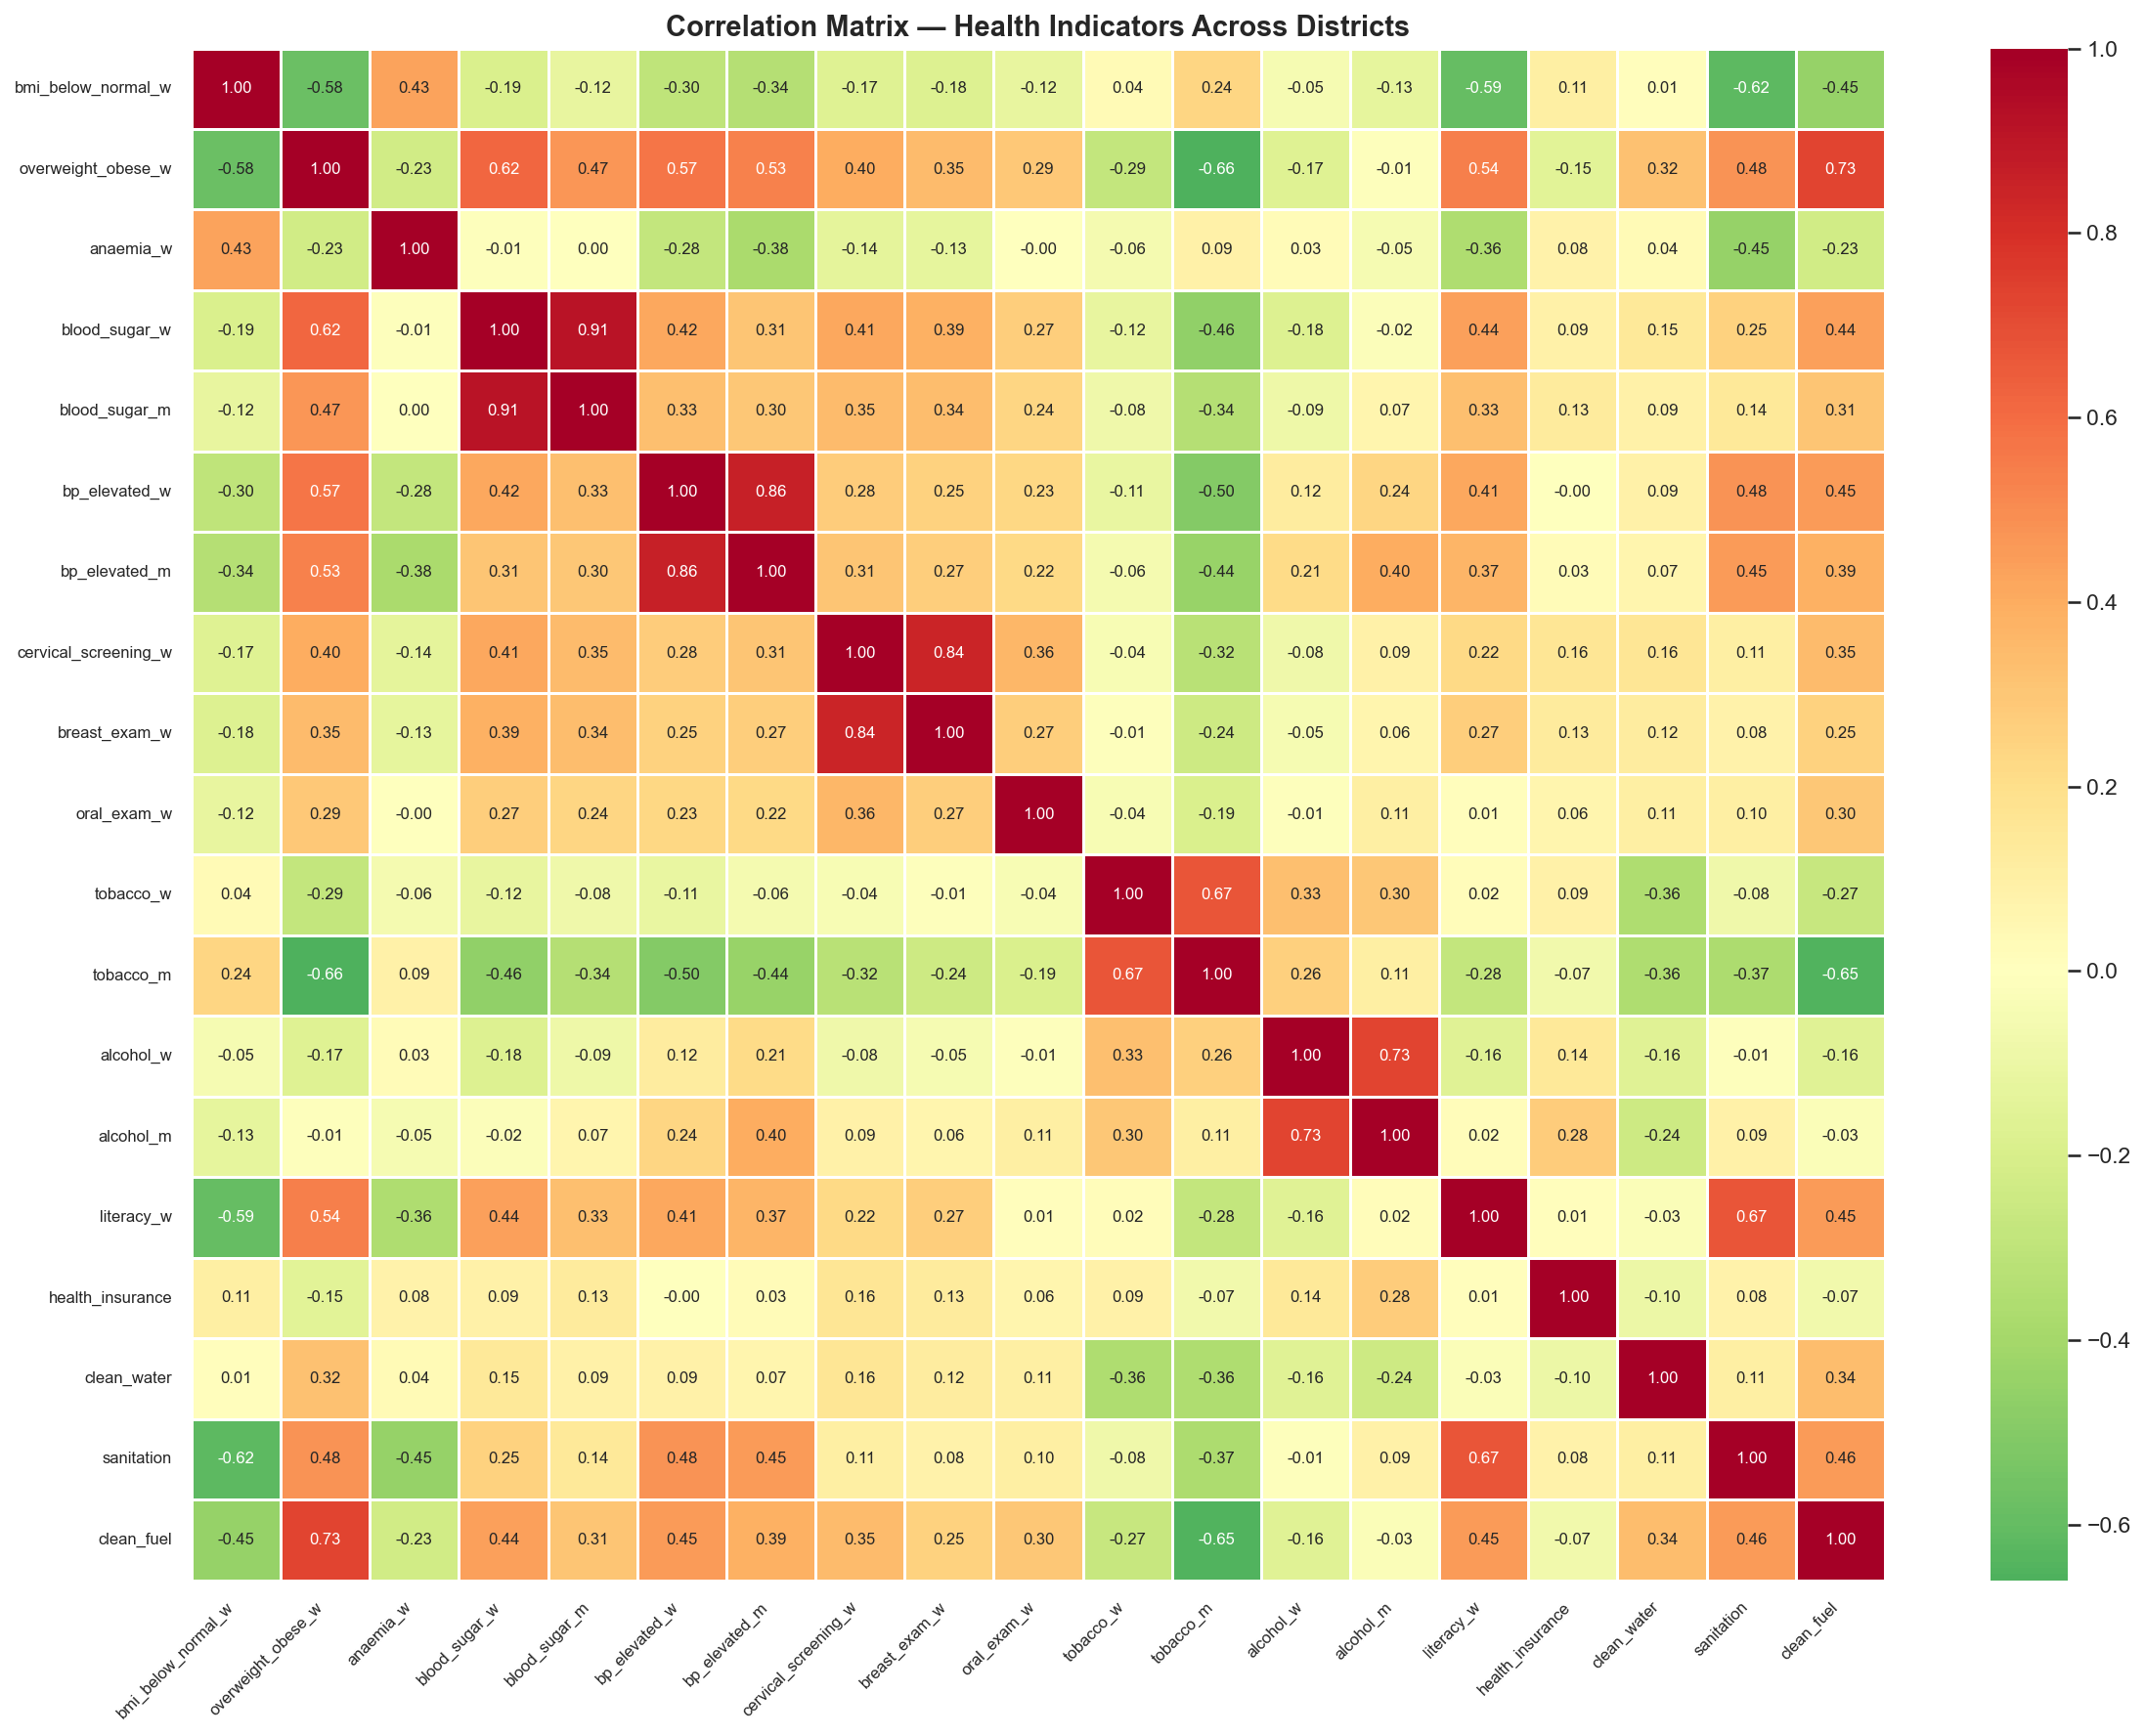

Done


In [4]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df.drop(columns=['district', 'state']).corr().round(2)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, annot_kws={'size': 8})

plt.title('Correlation Matrix — Health Indicators Across Districts',
          fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/03_correlation_heatmap.png', dpi=300, 
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Correlation heatmap saved")
print("Done")

## Finding 3: Correlation Analysis — Key Insights

**Strong Positive Correlations (closer to 1.0):**

- **blood_sugar_w & blood_sugar_m (0.91)** — Diabetes risk is highly 
  consistent across genders in the same district, suggesting shared 
  dietary and lifestyle patterns at district level rather than 
  gender-specific factors.

- **bp_elevated_w & bp_elevated_m (0.86)** — Hypertension follows 
  the same pattern — where women have high BP, men do too. 
  Environmental and lifestyle factors dominate over gender differences, 
  pointing to district-level systemic causes.

- **cervical_screening_w & breast_exam_w (0.84)** — Districts with 
  better cervical screening also have better breast examination coverage. 
  This indicates overall healthcare access quality rather than 
  disease-specific awareness — where one screening exists, others follow.

- **tobacco_w & tobacco_m (0.67)** — Tobacco use is culturally and 
  regionally driven — both genders consume more in the same districts, 
  suggesting social normalization of tobacco in certain geographies.

- **alcohol_w & alcohol_m (0.73)** — Same pattern as tobacco — 
  alcohol consumption is a district-level cultural phenomenon, 
  not an individual choice in isolation.

**Strong Negative Correlations (closer to -1.0):**

- **literacy_w & bmi_below_normal_w (-0.59)** — Higher female 
  literacy correlates with lower undernutrition. Educated women 
  make better dietary decisions, are more aware of nutrition, 
  and are more likely to seek healthcare — directly reducing 
  underweight prevalence.

- **sanitation & bmi_below_normal_w (-0.62)** — Districts with 
  better sanitation show significantly lower female undernutrition. 
  The mechanism is indirect but well-established in public health: 
  poor sanitation → frequent infections (diarrhoea, parasitic diseases) 
  → nutrients not absorbed properly → chronic undernutrition even when 
  food is available. This means undernutrition in India is not purely 
  a food availability problem — it is equally a sanitation and 
  disease burden problem.

- **tobacco_m & overweight_obese_w (-0.66)** — Districts with high 
  male tobacco use show lower female obesity — this is NOT causal. 
  Both variables are proxies for rural districts: rural men smoke 
  more while rural women have lower obesity due to physically active 
  lifestyles and less processed food consumption.

- **tobacco_m & clean_fuel (-0.65)** — Districts with high male 
  tobacco use have poor clean fuel access — a strong rural poverty 
  indicator. Rural districts lack LPG/clean energy access, forcing 
  dependence on biomass, while tobacco culture is deeply embedded 
  in the same communities.

**Interconnected Social Development:**

- **literacy_w & sanitation (0.67)** — Literate districts consistently 
  show better sanitation infrastructure. This is not coincidental — 
  female literacy drives demand for better living conditions. 
  Educated women are more likely to advocate for sanitation facilities, 
  participate in local governance, and adopt hygienic practices. 
  This creates a positive feedback loop: literacy → sanitation → 
  lower infections → better nutrition → healthier children → 
  higher school attendance → more literacy. Social development 
  indicators do not improve in isolation — they reinforce each other.

**Key Takeaway:** Literacy and sanitation are the strongest social 
determinants of health in this dataset. Districts investing in 
female education and basic infrastructure show measurable improvement 
across ALL health indicators — making them the highest-ROI intervention 
points for policymakers and healthcare providers.

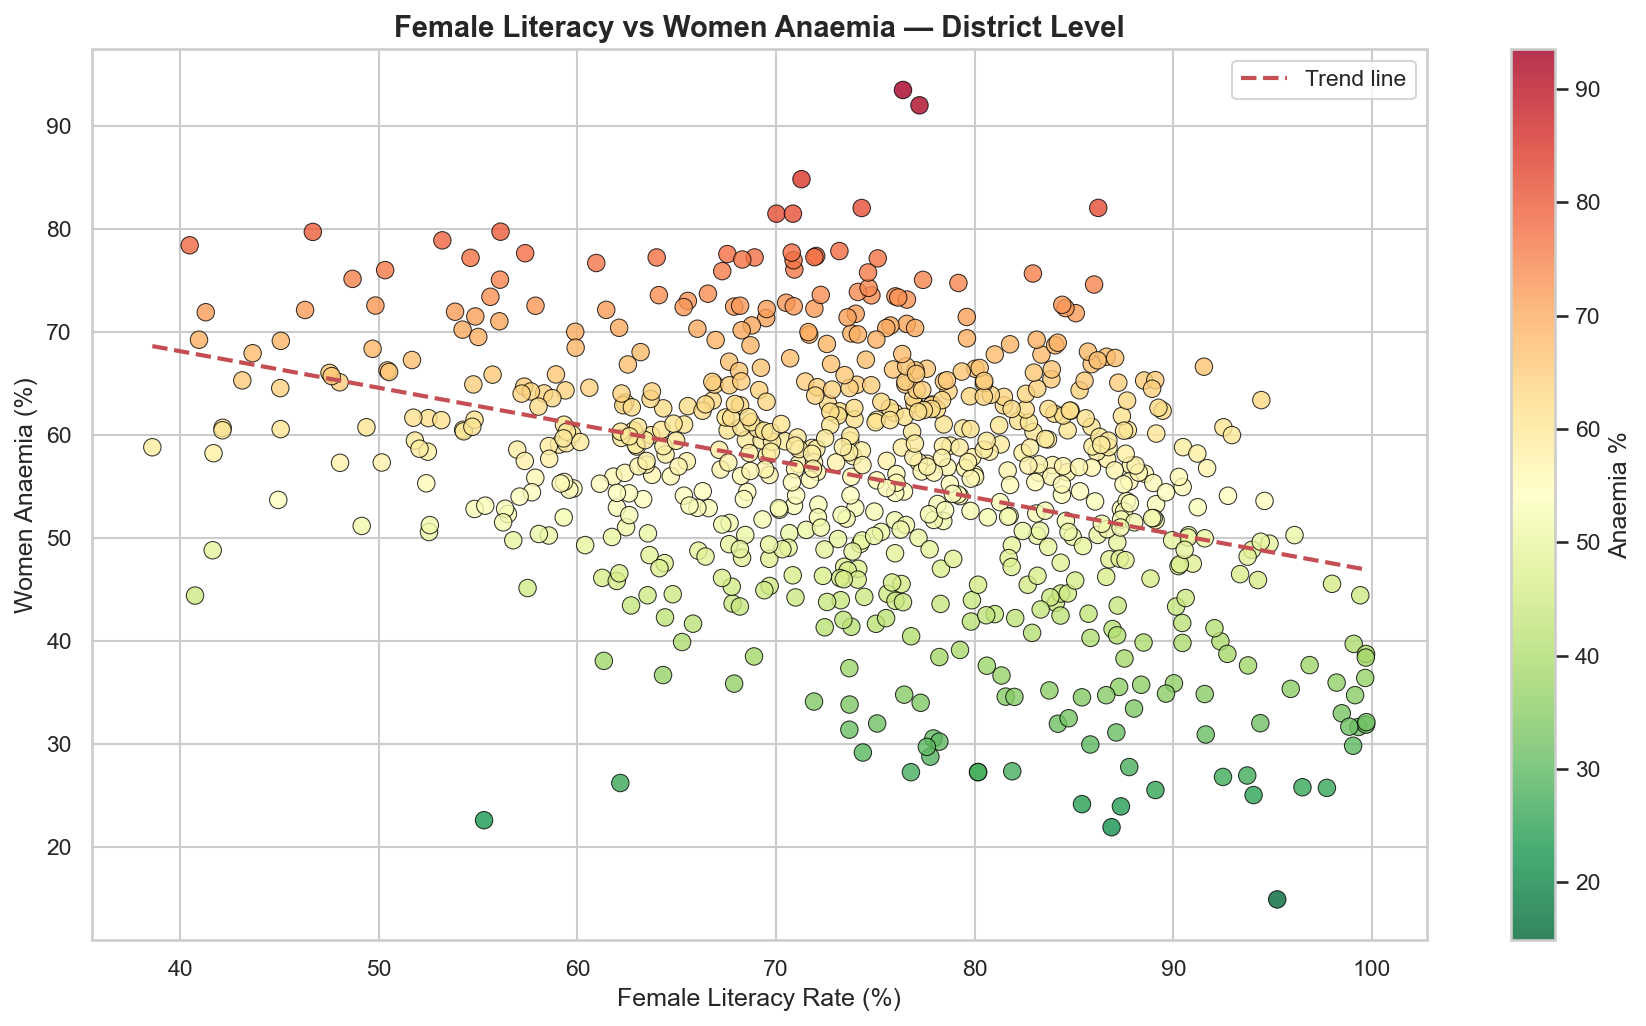

Done


In [5]:
# Scatter plot — Literacy vs Anaemia
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['literacy_w'], df['anaemia_w'],
                      alpha=0.8, c=df['anaemia_w'], 
                      cmap='RdYlGn_r', edgecolors='black', 
                      linewidth=0.5, s=70)

plt.colorbar(scatter, label='Anaemia %')
plt.title('Female Literacy vs Women Anaemia — District Level',
          fontweight='bold', fontsize=14)
plt.xlabel('Female Literacy Rate (%)', fontsize=12)
plt.ylabel('Women Anaemia (%)', fontsize=12)

# Trend line
z = np.polyfit(df['literacy_w'], df['anaemia_w'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['literacy_w']), p(sorted(df['literacy_w'])),
         'r--', linewidth=2, label='Trend line')
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/04_literacy_vs_anaemia.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Literacy vs Anaemia scatter saved")
print("Done")

## Finding 4: Female Literacy vs Women Anaemia

**Observation:** Clear negative trend — as female literacy increases,
women anaemia prevalence decreases across Indian districts.

**Key insights from scatter:**

- **Low literacy (40-55%) districts** — majority cluster in 65-80% 
  anaemia range (red/orange dots) — highest risk zone.

- **High literacy (85-100%) districts** — majority shift to 30-55% 
  anaemia range (green dots) — significantly better outcomes.

- **Outliers worth noting:** Few high-literacy districts still show 
  high anaemia — suggesting literacy alone is not sufficient, 
  sanitation and dietary access must accompany it.

- **Trend line confirms:** Every 10% increase in female literacy 
  corresponds to approximately 2-3% reduction in anaemia prevalence 
  at district level.

**Business Implication:** For health insurers and NGOs — female 
education investment yields measurable health ROI. Districts with 
low literacy are highest priority intervention zones.

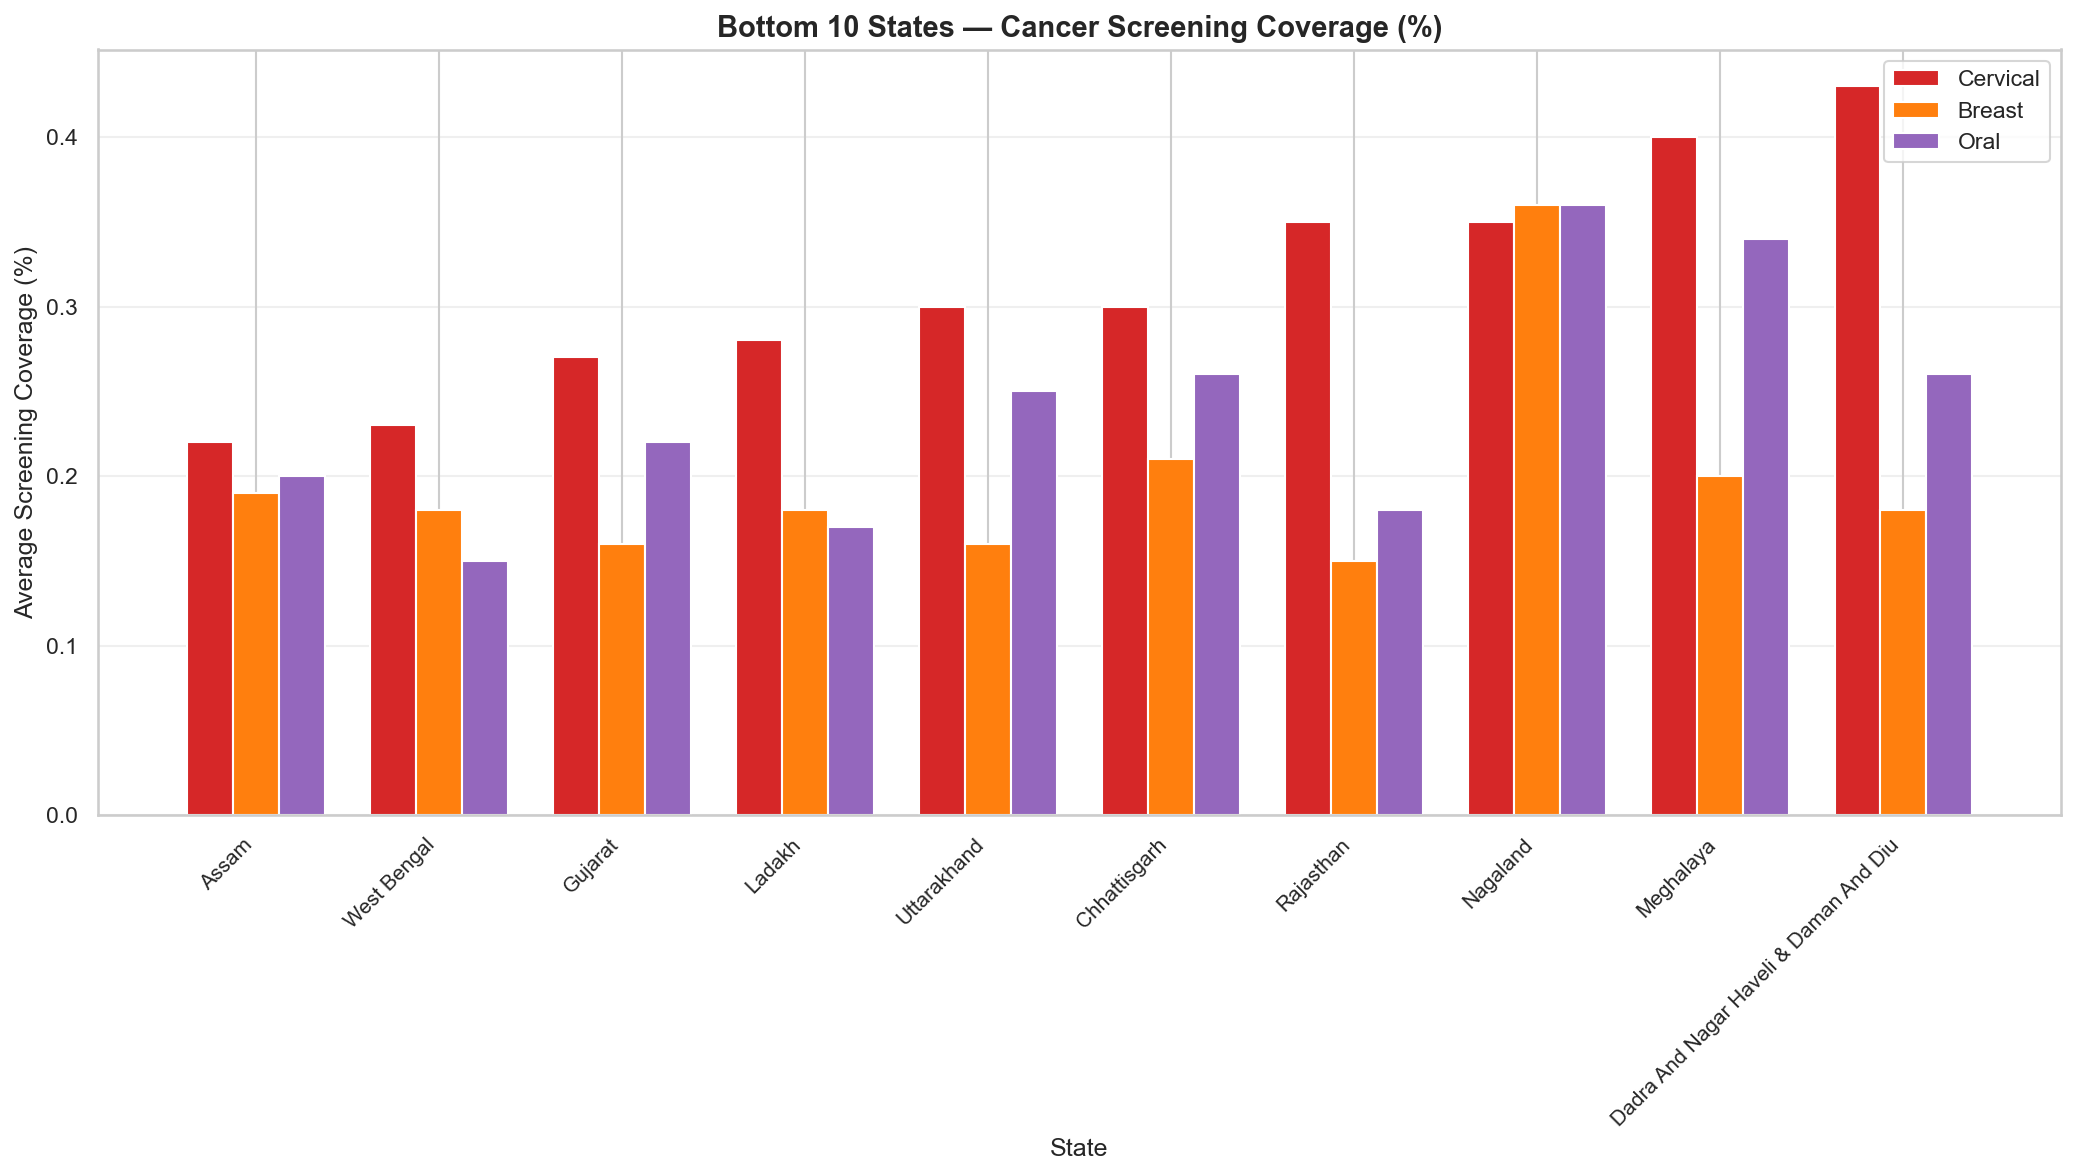

Done


In [7]:
# Bottom 10 states by cervical cancer screening
state_cancer = df.groupby('state')[['cervical_screening_w', 
                                     'breast_exam_w', 
                                     'oral_exam_w']].mean().round(2)

bottom_cancer = state_cancer.sort_values('cervical_screening_w').head(10)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(bottom_cancer.index))
width = 0.25

bars1 = ax.bar(x - width, bottom_cancer['cervical_screening_w'], 
               width, label='Cervical', color='#d62728')
bars2 = ax.bar(x, bottom_cancer['breast_exam_w'], 
               width, label='Breast', color='#ff7f0e')
bars3 = ax.bar(x + width, bottom_cancer['oral_exam_w'], 
               width, label='Oral', color='#9467bd')

ax.set_title('Bottom 10 States — Cancer Screening Coverage (%)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Average Screening Coverage (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(bottom_cancer.index, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/05_cancer_screening.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Cancer screening chart saved")
print("Done")

## Finding 5: Cancer Screening — Critically Low Coverage

**Overall Picture:**
Cancer screening coverage across India is alarmingly low
average cervical screening at just 1.57%, breast examination 
at 0.65%, and oral cavity examination at 0.70% nationally.

**State Pattern:**
- 4-5 of the bottom 10 states are from East and Northeast India
  Assam, Tripura, Meghalaya, Manipur, West Bengal region.
  Geographic isolation, limited specialist healthcare facilities,
  and low awareness are primary drivers.

- **Cervical screening is consistently the lowest** across all 
  states despite being the most preventable cancer in women 
  through HPV vaccination and early detection.

- **All three screening types follow same pattern per state**
  districts/states with poor cervical screening also have poor 
  breast and oral screening, confirming it is a systemic 
  healthcare access problem, not disease-specific.

**Business Implication:** 
Northeast and East India represent the highest unmet need for 
cancer screening programs priority zones for NGOs, 
health insurers, and government outreach campaigns.

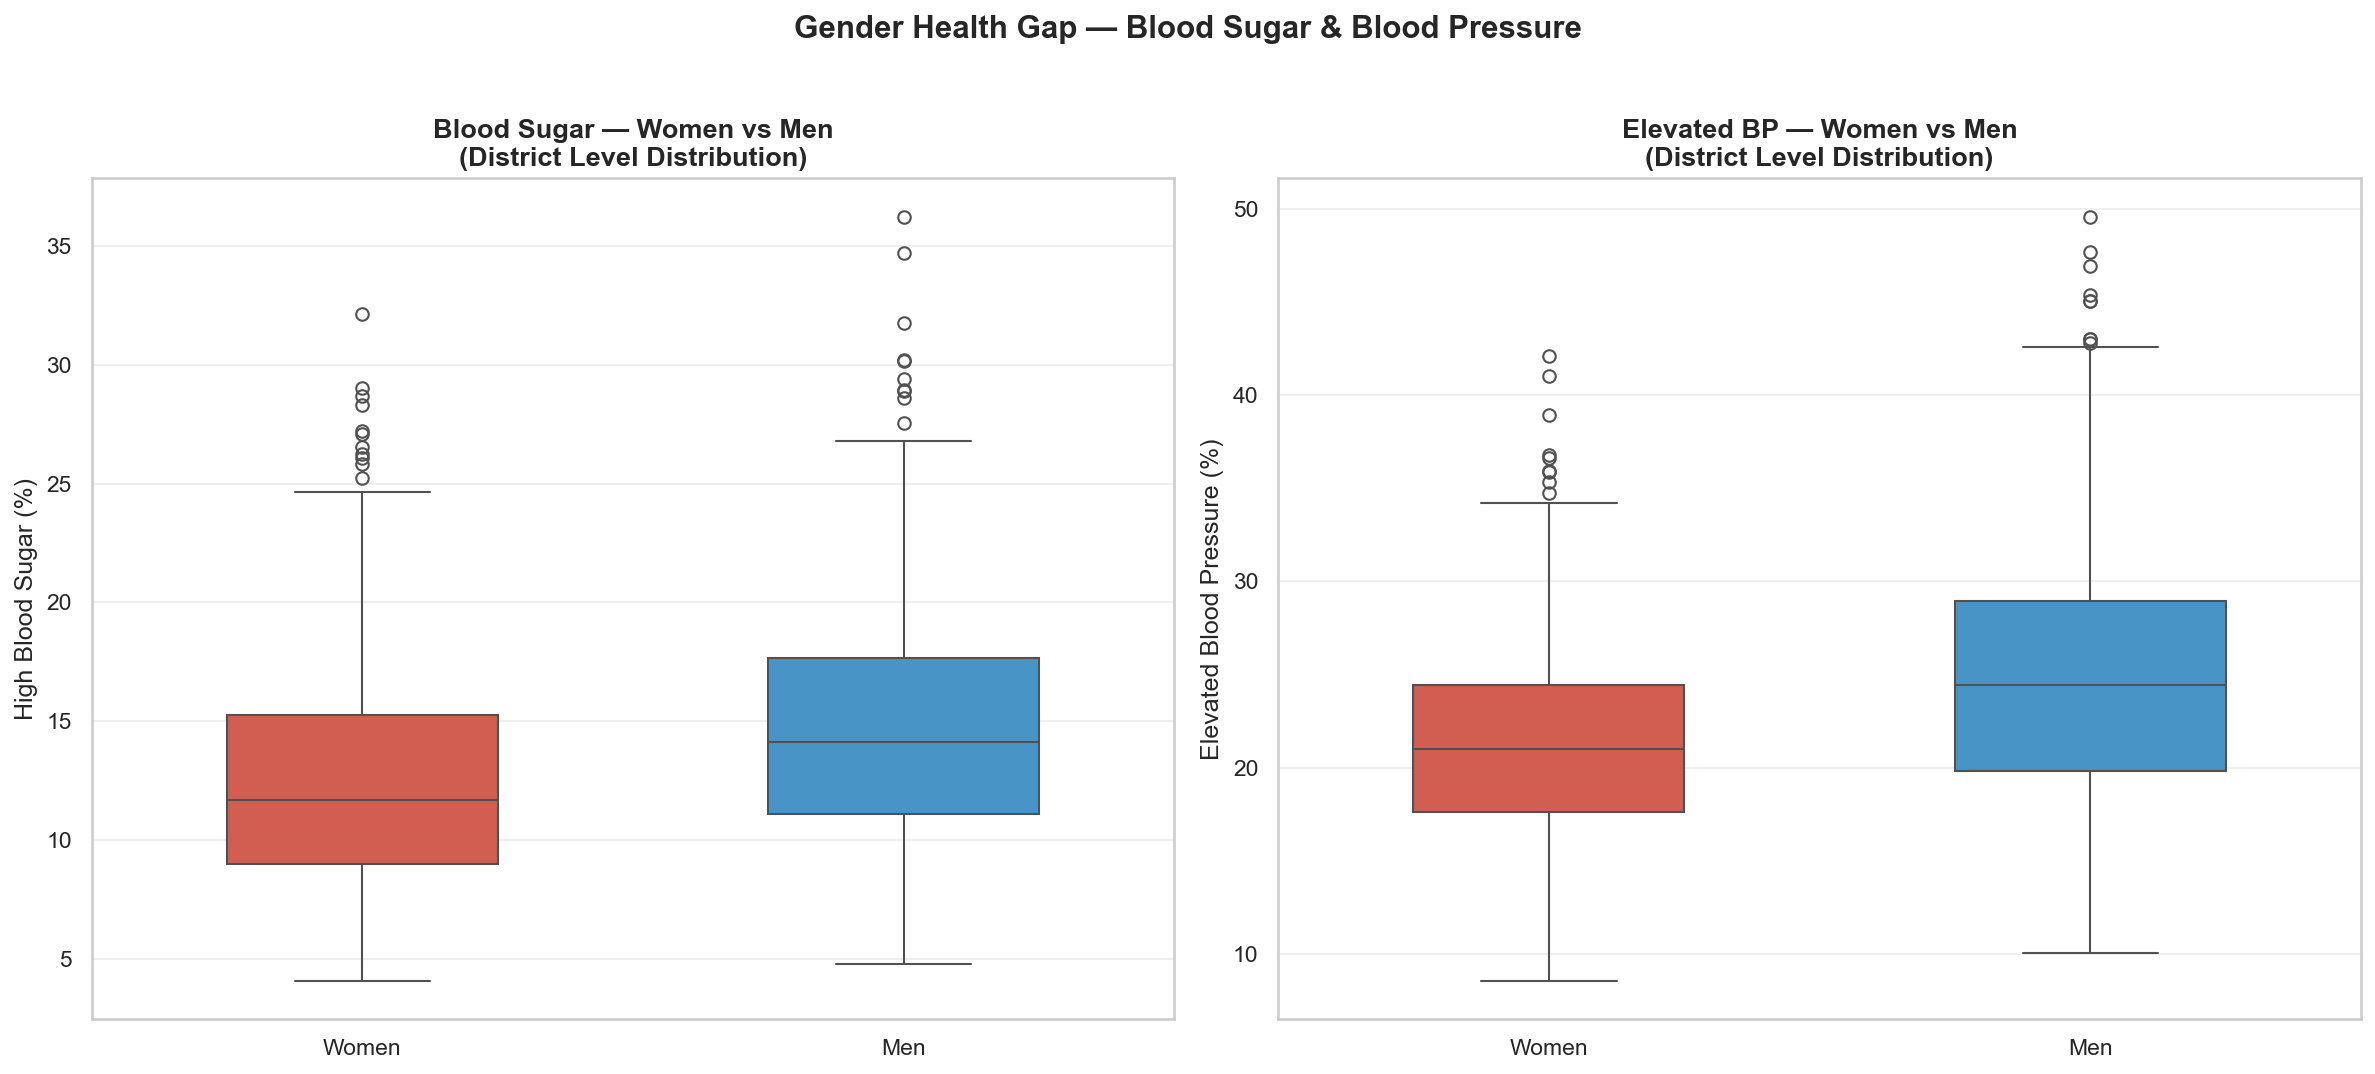

Done


In [9]:
# Gender comparison — Blood Sugar and BP
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Blood Sugar comparison
blood_sugar_data = pd.DataFrame({
    'Women': df['blood_sugar_w'],
    'Men': df['blood_sugar_m']
})
blood_sugar_melted = blood_sugar_data.melt(var_name='Gender', value_name='Blood Sugar %')

sns.boxplot(x='Gender', y='Blood Sugar %', data=blood_sugar_melted,
            hue='Gender', palette={'Women': '#e74c3c', 'Men': '#3498db'},
            ax=axes[0], width=0.5, legend=False)
axes[0].set_title('Blood Sugar — Women vs Men\n(District Level Distribution)',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('High Blood Sugar (%)', fontsize=12)
axes[0].set_xlabel('')
axes[0].grid(axis='y', alpha=0.3)

# BP comparison
bp_data = pd.DataFrame({
    'Women': df['bp_elevated_w'],
    'Men': df['bp_elevated_m']
})
bp_melted = bp_data.melt(var_name='Gender', value_name='BP %')

sns.boxplot(x='Gender', y='BP %', data=bp_melted,
            hue='Gender', palette={'Women': '#e74c3c', 'Men': '#3498db'},
            ax=axes[1], width=0.5, legend=False)
axes[1].set_title('Elevated BP — Women vs Men\n(District Level Distribution)',
                   fontweight='bold', fontsize=13)
axes[1].set_ylabel('Elevated Blood Pressure (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Gender Health Gap — Blood Sugar & Blood Pressure',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/06_gender_comparison.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Gender comparison chart saved")
print("Done")

## Finding 6: Gender Health Gap — Blood Sugar & Blood Pressure

**Blood Sugar:**
- Men (median ~14.5%) consistently higher than Women (median ~12%) 
  across all districts.
- Men's distribution is wider more variability across districts,
  suggesting lifestyle factors like diet and alcohol play bigger role.
- Both genders show outliers above 28-36% in some districts 
  extreme diabetes burden in specific regions.

**Blood Pressure:**
- Men (median ~25%) significantly higher than Women (median ~21%)
  across all districts.
- Men's IQR is larger wider spread indicating more district-level
  variation in hypertension.
- Men show more high-end outliers (45-50%) extreme hypertension
  districts are predominantly male-driven.

**Key Takeaway:** Men are at consistently higher risk for both 
diabetes and hypertension across Indian districts. Combined with 
higher tobacco and alcohol use, men represent a higher-risk 
demographic for cardiovascular and metabolic diseases yet 
healthcare seeking behavior in men is typically lower than women.

**Business Implication:** Health insurers should price male 
risk premiums higher in high-tobacco, high-BP districts. 
Targeted male health awareness campaigns needed in districts 
with BP outliers above 40%.

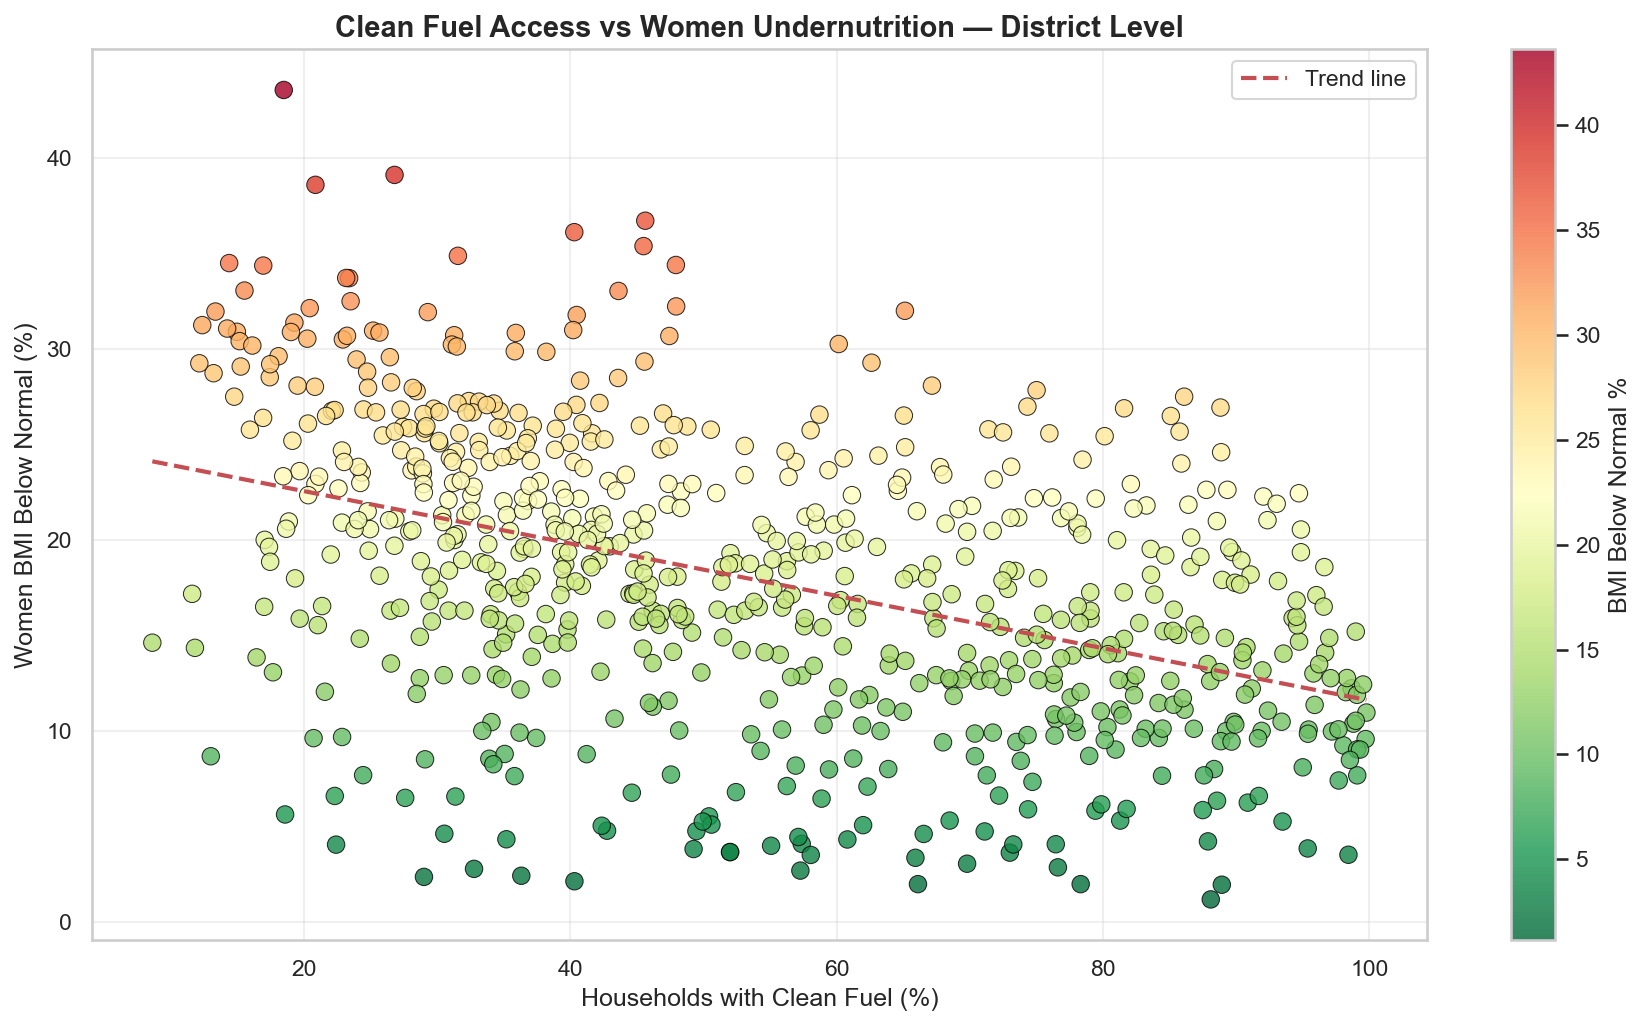

Done


In [10]:
# Clean fuel vs BMI below normal
plt.figure(figsize=(12, 7))

scatter = plt.scatter(df['clean_fuel'], df['bmi_below_normal_w'],
                      alpha=0.8, c=df['bmi_below_normal_w'],
                      cmap='RdYlGn_r', edgecolors='black',
                      linewidth=0.5, s=70)

plt.colorbar(scatter, label='BMI Below Normal %')
plt.title('Clean Fuel Access vs Women Undernutrition — District Level',
          fontweight='bold', fontsize=14)
plt.xlabel('Households with Clean Fuel (%)', fontsize=12)
plt.ylabel('Women BMI Below Normal (%)', fontsize=12)

# Trend line
z = np.polyfit(df['clean_fuel'], df['bmi_below_normal_w'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['clean_fuel']), p(sorted(df['clean_fuel'])),
         'r--', linewidth=2, label='Trend line')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/07_cleanfuel_vs_bmi.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Clean fuel vs BMI chart saved")
print("Done")

## Finding 7: Clean Fuel Access vs Women Undernutrition

**Observation:** Districts with lower clean fuel access show 
significantly higher women undernutrition (BMI below normal).

**Key insights:**

- **Low clean fuel (15-30%) districts** — majority cluster in 
  25-43% undernutrition range (red/orange dots) — highest risk zone.

- **High clean fuel (80-100%) districts** — majority shift to 
  5-15% undernutrition range (green dots) — dramatically better 
  nutritional outcomes.

- **Outliers on left:** Few low clean fuel districts show very low 
  BMI below normal likely tribal districts where body composition 
  patterns differ, or data collection variations.

- **Trend line confirms** negative relationship as clean fuel 
  access increases, women undernutrition decreases consistently.

**Why this connection exists:**
Biomass cooking (wood, dung, coal) causes indoor air pollution → 
chronic respiratory infections → reduced oxygen efficiency → 
poor nutrient absorption → undernutrition. Clean fuel breaks 
this chain directly.

Additionally, clean fuel districts are economically better off 
better food access, better healthcare, better literacy all 
compounding into better nutritional outcomes.

**Business Implication:** Clean fuel access is a leading indicator 
of district health status districts below 40% clean fuel access 
should be flagged as high priority intervention zones regardless 
of other indicators.

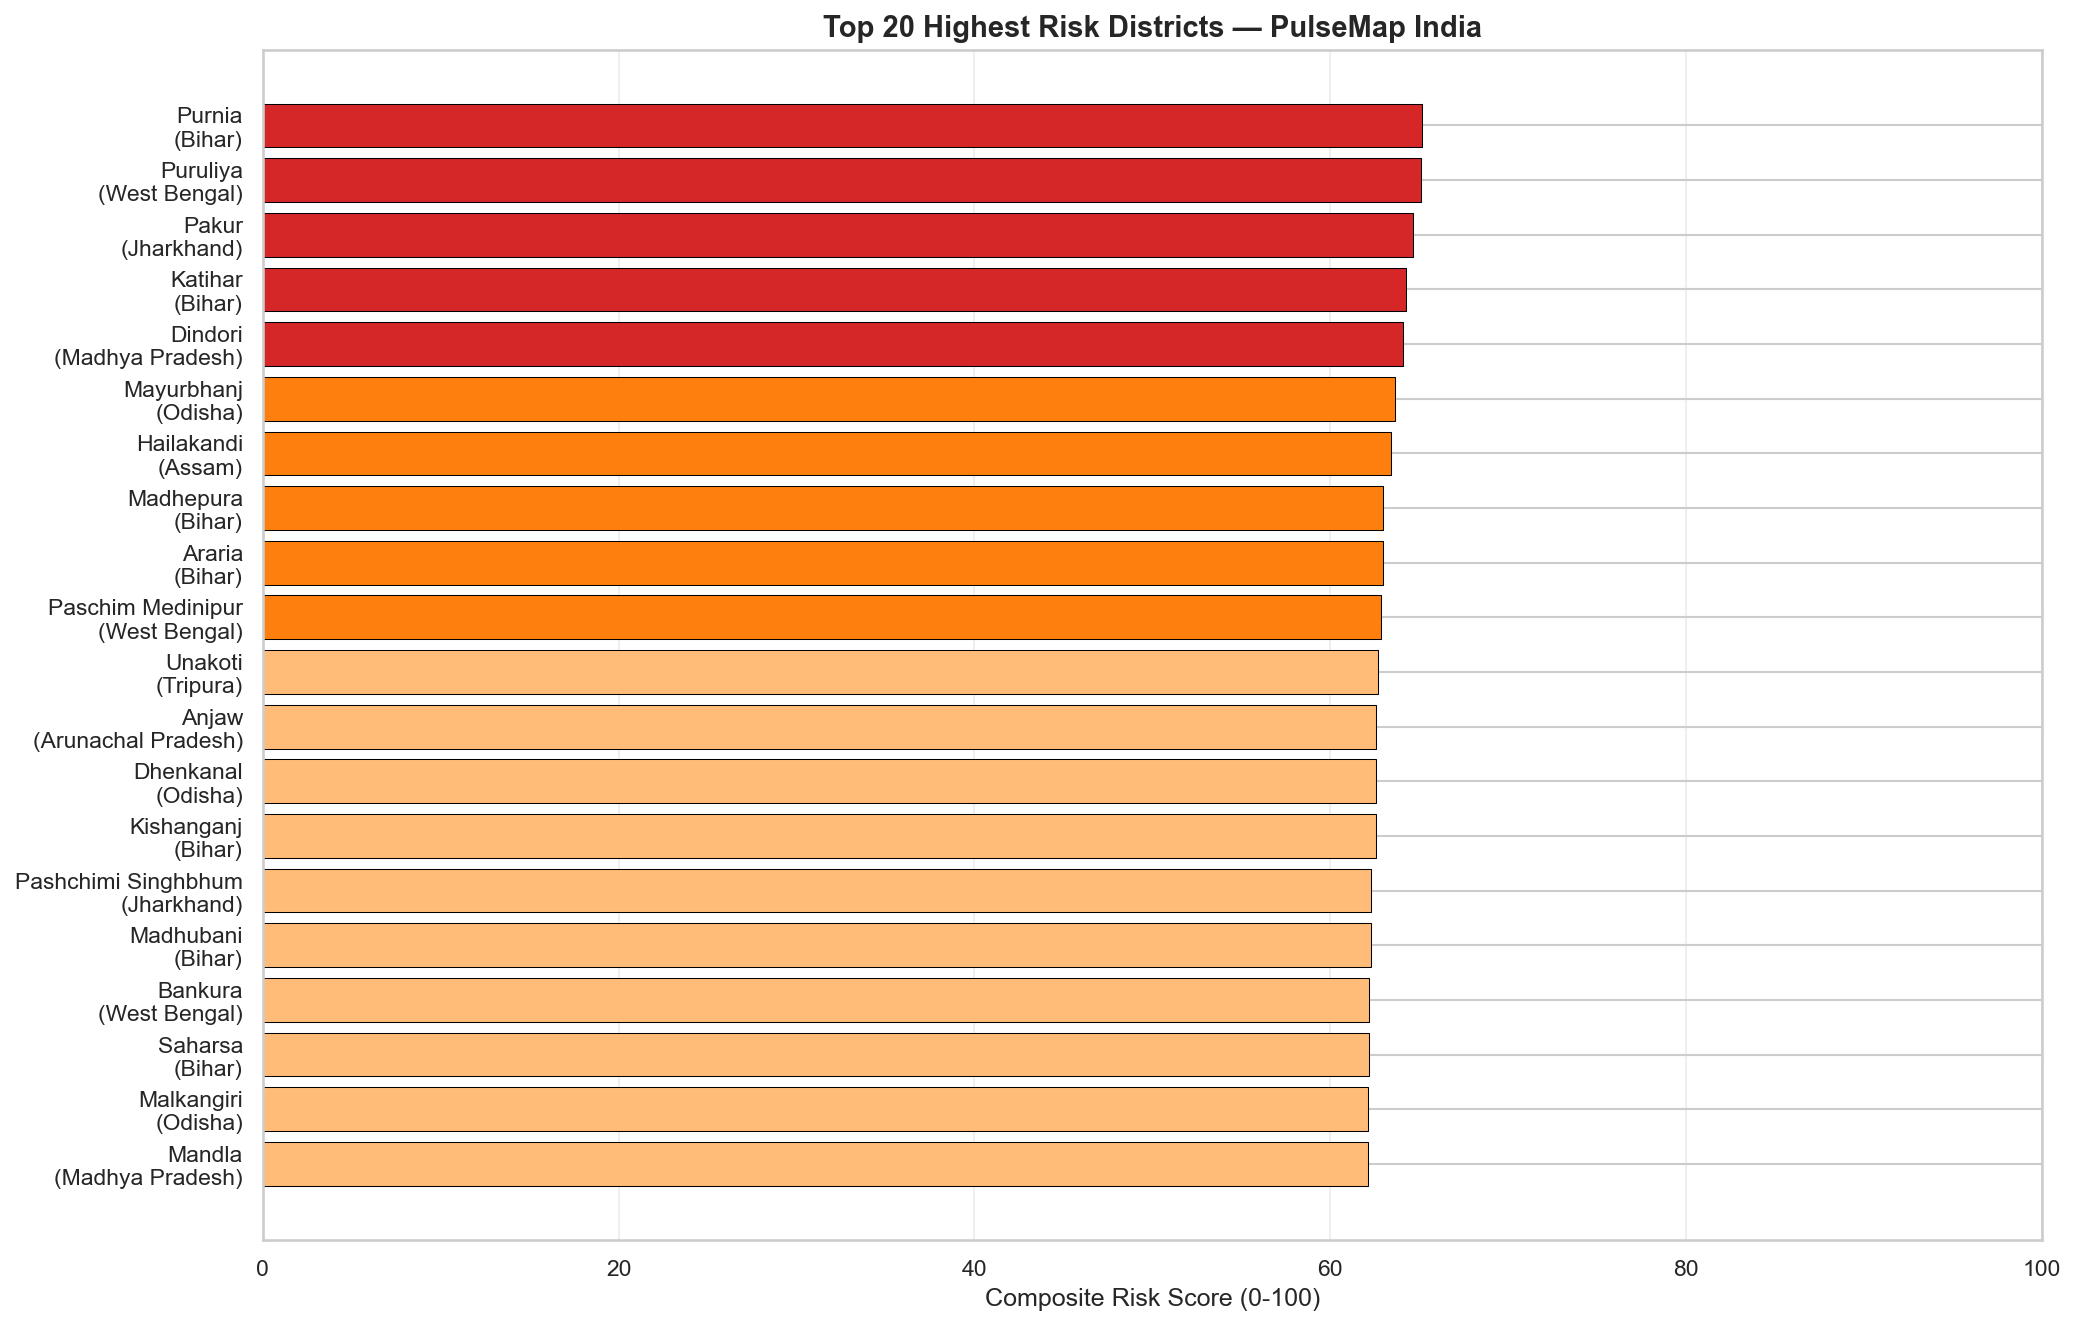

Done

Top 20 Districts:
           district             state  composite_score
             Purnia             Bihar        65.138093
           Puruliya       West Bengal        65.108387
              Pakur         Jharkhand        64.629746
            Katihar             Bihar        64.239187
            Dindori    Madhya Pradesh        64.091436
         Mayurbhanj            Odisha        63.613490
         Hailakandi             Assam        63.387995
          Madhepura             Bihar        62.954290
             Araria             Bihar        62.953222
  Paschim Medinipur       West Bengal        62.878258
            Unakoti           Tripura        62.662563
              Anjaw Arunachal Pradesh        62.588377
          Dhenkanal            Odisha        62.587006
         Kishanganj             Bihar        62.585968
Pashchimi Singhbhum         Jharkhand        62.292609
          Madhubani             Bihar        62.269512
            Bankura       West Bengal    

In [11]:
# Top 20 highest risk districts — composite score
# Simple average of key risk indicators
risk_cols = ['anaemia_w', 'blood_sugar_w', 'blood_sugar_m',
             'bp_elevated_w', 'bp_elevated_m', 'tobacco_m']

# Reverse indicators — higher value = lower risk
reverse_cols = ['literacy_w', 'clean_fuel', 'sanitation',
                'clean_water', 'health_insurance',
                'cervical_screening_w', 'breast_exam_w', 'oral_exam_w']

# Normalize 0-100
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_norm = df.copy()
df_norm[risk_cols] = scaler.fit_transform(df[risk_cols])
df_norm[reverse_cols] = 1 - scaler.fit_transform(df[reverse_cols])

# Simple composite score
all_risk_cols = risk_cols + reverse_cols
df_norm['composite_score'] = df_norm[all_risk_cols].mean(axis=1) * 100

# Top 20
top20 = df_norm.nlargest(20, 'composite_score')[
    ['district', 'state', 'composite_score']].reset_index(drop=True)

# Plot
plt.figure(figsize=(14, 9))
colors = ['#d62728' if i < 5 else '#ff7f0e' if i < 10 
          else '#ffbb78' for i in range(20)]

bars = plt.barh(top20['district'] + '\n(' + top20['state'] + ')',
                top20['composite_score'],
                color=colors, edgecolor='black', linewidth=0.5)

plt.xlabel('Composite Risk Score (0-100)', fontsize=12)
plt.title('Top 20 Highest Risk Districts — PulseMap India',
          fontweight='bold', fontsize=14)
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/08_top20_risk_districts.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

logging.info("Top 20 risk districts chart saved")
print("Done")
print("\nTop 20 Districts:")
print(top20.to_string(index=False))

## Finding 8: Top 20 Highest Risk Districts — PulseMap India

### How was this Risk Score calculated?

Each district was scored on 14 health and socioeconomic indicators 
from NFHS-5. Indicators were split into two categories:

**Risk indicators** (higher = more risk):
Anaemia, Blood Sugar (Women & Men), Elevated BP (Women & Men), 
Male Tobacco Use

**Protective indicators** (higher = less risk):
Female Literacy, Clean Fuel, Sanitation, Clean Water, 
Health Insurance, Cervical/Breast/Oral Cancer Screening

All indicators were normalized to a 0-1 scale using Min-Max 
scaling to remove unit bias. Protective indicators were 
inverted (1 - value) so that higher always means higher risk. 
Final composite score is the average of all 14 normalized 
indicators, scaled to 0-100.

**Higher score = Higher preventable disease risk.**

*Note: This is an exploratory composite index, not a clinical 
risk model. A more rigorous weighted model is built in the 
Risk Scoring notebook (03_risk_scoring.ipynb).*

---

**Geographic Pattern:**
Top 20 highest risk districts are concentrated in just 7 states:
- **Bihar** — 7 districts (Purnia, Katihar, Madhepura, Araria, 
  Kishanganj, Madhubani, Saharsa)
- **West Bengal** — 3 districts
- **Odisha** — 3 districts
- **Jharkhand** — 2 districts
- **Madhya Pradesh** — 2 districts
- **Assam** — 1 district
- **Arunachal Pradesh** — 1 district

**Top 5 Critical Risk Districts (score 64+):**
1. Purnia, Bihar — 65.1
2. Puruliya, West Bengal — 65.1
3. Pakur, Jharkhand — 64.6
4. Katihar, Bihar — 64.2
5. Dindori, Madhya Pradesh — 64.1

**Key Observations:**
- **Bihar dominates** with 7 out of 20 districts combination of 
  high anaemia, low literacy, poor sanitation, and minimal 
  cancer screening creates compounding risk.

- **Score range is narrow (62-65)** all 20 districts are 
  closely clustered, indicating a systemic regional problem 
  rather than isolated district-level failures.

- **Arunachal Pradesh (Anjaw)** is an outlier extremely remote 
  district with near-zero healthcare access, geographic isolation 
  drives risk despite small population.

- **No Southern or Western Indian districts** in top 20 
  confirms the North-East India health divide is real and 
  data-backed.

**Business Implication:**
For health insurers these 20 districts represent highest 
claim probability zones. For NGOs and government Bihar alone 
needs 7 district-level interventions simultaneously. 
A coordinated state-level program would be more effective 
than district-by-district approach.